# 03 · Volúmenes: centralización (P2) y origen (P3)

**Objetivo:** medir qué parte del volumen se registra en la RM (P2) y cómo evoluciona la participación del origen extranjero (P3)
**Preguntas que responde:** P2, P3
**Entrada:** `data/processed/precios_limpio.parquet`
**Salida:** `images/p2_participacion_rm.png`, `images/p3_origen_extranjero.png`
**Decisiones tomadas:** D-07, D-14, D-15, D-20, D-21

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/precios_limpio.parquet")

# D-07: mismos meses en todos los años
b = df[df["mes"] <= 9].copy()
for c in ["producto", "unidad", "mercado"]:
    b[c] = b[c].astype(str)

print(len(df), "->", len(b), "filas (enero a septiembre)")
print(b.groupby("anio").size())

1297334 -> 1004073 filas (enero a septiembre)
anio
2020    142961
2021    145098
2022    142277
2023    141882
2024    140213
2025    151700
2026    139942
dtype: int64


In [2]:
b["vol_rm"] = b["volumen"].where(b["es_rm"], 0)
b["m_rm"] = b["mercado"].where(b["es_rm"])
b["m_otro"] = b["mercado"].where(~b["es_rm"])

g = (b.groupby(["producto", "unidad", "anio"])
       .agg(vol_total=("volumen", "sum"), vol_rm=("vol_rm", "sum"))
       .reset_index())
g["share_rm"] = g["vol_rm"] / g["vol_total"]

cob = (b.groupby(["producto", "unidad"])
         .agg(mercados_rm=("m_rm", "nunique"), mercados_otro=("m_otro", "nunique"),
              filas_tot=("volumen", "size")).reset_index())
cob = cob.merge(g.groupby(["producto", "unidad"])["anio"].nunique()
                  .rename("n_anios").reset_index(), on=["producto", "unidad"])

print("Grupos (producto, unidad):", len(cob))
mixtos = cob[(cob["mercados_rm"] >= 1) & (cob["mercados_otro"] >= 1)]
print("Con mercados de la RM y de fuera:", len(mixtos))
panel = mixtos[mixtos["n_anios"] == 7]
print("Presentes los 7 años:", len(panel))
for k in [200, 500, 1000, 2000]:
    print(f"  con al menos {k} filas:", (panel["filas_tot"] >= k).sum())

Grupos (producto, unidad): 624
Con mercados de la RM y de fuera: 338
Presentes los 7 años: 214
  con al menos 200 filas: 186
  con al menos 500 filas: 160
  con al menos 1000 filas: 130
  con al menos 2000 filas: 104


In [3]:
MIN_FILAS = 500
claves = panel.loc[panel["filas_tot"] >= MIN_FILAS, ["producto", "unidad"]]
gp = g.merge(claves, on=["producto", "unidad"])
print(len(claves), "grupos en el panel\n")

res = gp.groupby("anio")["share_rm"].quantile([.25, .5, .75]).unstack().mul(100).round(1)
res["media"] = (gp.groupby("anio")["share_rm"].mean() * 100).round(1)
print("% del volumen en la RM, por año (entre grupos):")
print(res)

w = gp.pivot_table(index=["producto", "unidad"], columns="anio", values="share_rm")
d = (w[2026] - w[2020]) * 100
print("\nCambio 2020 -> 2026 en puntos porcentuales, por grupo:")
print(d.describe().round(1))
print("suben >2 pp:", (d > 2).sum(), "| bajan >2 pp:", (d < -2).sum(),
      "| estables:", (d.abs() <= 2).sum())

# Robustez: misma pregunta contando filas en vez de volumen
fm = b.merge(claves, on=["producto", "unidad"])
print("\n% de filas en la RM, mismo panel:")
print((fm.groupby("anio")["es_rm"].mean() * 100).round(1))

160 grupos en el panel

% del volumen en la RM, por año (entre grupos):
      0.25   0.5  0.75  media
anio                         
2020  23.2  51.7  73.1   48.9
2021  19.3  49.0  72.0   46.7
2022  17.5  47.6  67.9   46.3
2023   7.0  45.5  71.7   44.6
2024  17.9  50.4  72.5   47.0
2025  13.4  49.4  69.0   44.8
2026   8.3  44.6  68.4   43.8

Cambio 2020 -> 2026 en puntos porcentuales, por grupo:
count    160.0
mean      -5.1
std       23.1
min      -96.4
25%      -17.3
50%       -2.0
75%        2.3
max       98.4
dtype: float64
suben >2 pp: 43 | bajan >2 pp: 80 | estables: 37

% de filas en la RM, mismo panel:
anio
2020    41.9
2021    42.8
2022    40.7
2023    39.1
2024    41.5
2025    41.9
2026    41.4
Name: es_rm, dtype: float64


In [4]:
k = b[b["tipo_unidad"] == "kilos_envase"].copy()
k["kg"] = k["volumen"] * k["kilos_unidad"]
k["kg_rm"] = k["kg"].where(k["es_rm"], 0)
kk = k.groupby(["producto", "anio"]).agg(kg=("kg", "sum"), kg_rm=("kg_rm", "sum"))
kk["pct_rm"] = kk["kg_rm"] / kk["kg"] * 100

top = kk.groupby("producto")["kg"].sum().nlargest(12).index
print("% en la RM (kilos), 12 productos con más volumen:")
print(kk.loc[kk.index.get_level_values("producto").isin(top), "pct_rm"].unstack().round(0))

% en la RM (kilos), 12 productos con más volumen:
anio       2020  2021  2022  2023  2024  2025  2026
producto                                           
Cebolla    52.0  57.0  52.0  59.0  59.0  62.0  68.0
Limón      49.0  45.0  56.0  58.0  54.0  58.0  55.0
Mandarina  39.0  43.0  45.0  44.0  41.0  46.0  30.0
Manzana    43.0  44.0  49.0  46.0  48.0  44.0  46.0
Naranja    42.0  43.0  57.0  57.0  48.0  49.0  43.0
Papa       70.0  64.0  67.0  65.0  68.0  70.0  65.0
Pera       44.0  47.0  50.0  41.0  41.0  40.0  39.0
Pimiento   39.0  35.0  31.0  31.0  42.0  40.0  31.0
Plátano    63.0  56.0  62.0  59.0  52.0  50.0  58.0
Tomate     53.0  47.0  47.0  47.0  59.0  57.0  52.0
Uva        44.0  48.0  50.0  44.0  44.0  46.0  47.0
Zanahoria  58.0  70.0  65.0  73.0  73.0  80.0  79.0


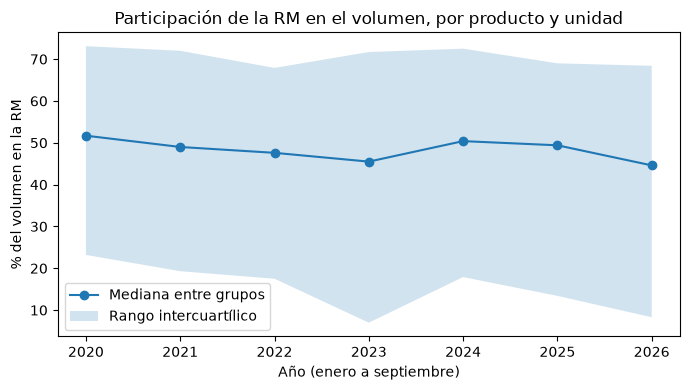

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(res.index, res[0.5], marker="o", label="Mediana entre grupos")
ax.fill_between(res.index, res[0.25], res[0.75], alpha=0.2, label="Rango intercuartílico")
ax.set(xlabel="Año (enero a septiembre)", ylabel="% del volumen en la RM",
       title="Participación de la RM en el volumen, por producto y unidad")
ax.legend()
fig.tight_layout()
fig.savefig("../images/p2_participacion_rm.png", dpi=150)

In [6]:
foco = ["Palta", "Poroto verde", "Sandia", "Zapallo", "Cebolla", "Limón", "Ajo"]

e = b[b["producto"].isin(foco)].copy()
e["ext"] = e["origen_tipo"].eq("Extranjero")
e["vol_ext"] = e["volumen"].where(e["ext"], 0)

lab = (e.groupby(["producto", "unidad"])
         .agg(filas=("volumen", "size"), prop_ext=("ext", "mean")).reset_index())
lab = lab[(lab["prop_ext"] > 0) & (lab["prop_ext"] < 1) & (lab["filas"] >= 300)]
principal = lab.sort_values("filas", ascending=False).drop_duplicates("producto")
print(principal.round(3).to_string(index=False))

    producto                       unidad  filas  prop_ext
       Palta $/kilo (en caja de 17 kilos)  30246     0.019
     Zapallo $/kilo (volumen en unidades)  18700     0.041
     Cebolla             $/malla 18 kilos  15833     0.068
         Ajo              $/caja 10 kilos   9149     0.895
      Sandia                     $/unidad   8851     0.018
Poroto verde             $/malla 25 kilos   5941     0.366
       Limón              $/caja 24 kilos   2194     0.933


In [7]:
ep = e.merge(principal[["producto", "unidad"]], on=["producto", "unidad"])
v = (ep.groupby(["producto", "anio"])
       .agg(vol=("volumen", "sum"), vol_ext=("vol_ext", "sum"),
            filas=("volumen", "size"), filas_ext=("ext", "sum")))
v["pct_vol"] = v["vol_ext"] / v["vol"] * 100
v["pct_filas"] = v["filas_ext"] / v["filas"] * 100

print("% del volumen extranjero (etiqueta principal de cada producto):")
print(v["pct_vol"].unstack().round(1))
print("\n% de filas extranjeras, mismas etiquetas:")
print(v["pct_filas"].unstack().round(1))

% del volumen extranjero (etiqueta principal de cada producto):
anio           2020  2021  2022  2023  2024  2025  2026
producto                                               
Ajo            86.2  99.0  95.3  94.8  94.7  98.2  92.6
Cebolla         9.3   3.7   3.3   7.2  23.2  10.9  25.1
Limón         100.0  99.9  96.5  97.7  98.2  97.7  98.9
Palta          23.7   4.9   1.6   0.0   0.1   0.0   0.0
Poroto verde   35.3  28.5  37.4  34.6  45.1  39.9  28.3
Sandia          0.4   0.5   0.1   0.1   0.2   0.4   0.1
Zapallo         3.7   4.0   2.6   5.4   2.5   6.4   9.4

% de filas extranjeras, mismas etiquetas:
anio           2020  2021  2022  2023  2024  2025  2026
producto                                               
Ajo            76.7  97.5  88.5  92.5  89.9  97.1  87.3
Cebolla         5.9  12.0   5.7   4.1  10.2   3.0   5.8
Limón         100.0  99.0  83.2  84.2  88.8  97.4  98.6
Palta          12.5   4.1   1.4   0.0   0.1   0.0   0.0
Poroto verde   33.9  33.2  33.1  46.4  47.2  33.8  30

In [8]:
a = e[e["producto"] == "Ajo"]
print(pd.crosstab(a["anio"], a["mercado"]))
print(pd.crosstab(a["anio"], a["origen"]).loc[:, lambda t: t.sum() > 300])

mercado  Agrícola del Norte S.A. de Arica  Femacal de La Calera  \
anio                                                              
2020                                   18                   292   
2021                                   12                   206   
2022                                    9                   281   
2023                                   27                   300   
2024                                   31                   282   
2025                                   22                   352   
2026                                    9                   437   

mercado  Feria Lagunitas de Puerto Montt  Macroferia Regional de Talca  \
anio                                                                     
2020                                 155                           103   
2021                                 140                           169   
2022                                 155                           167   
2023                      

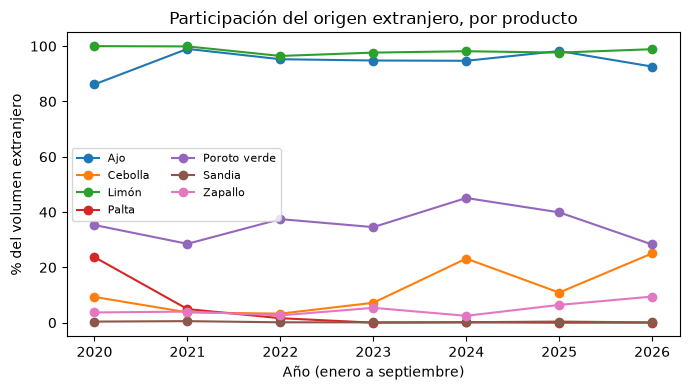

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for p, t in v["pct_vol"].unstack().iterrows():
    ax.plot(t.index, t.values, marker="o", label=p)
ax.set(xlabel="Año (enero a septiembre)", ylabel="% del volumen extranjero",
       title="Participación del origen extranjero, por producto")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig("../images/p3_origen_extranjero.png", dpi=150)

In [10]:
for p in ["Limón", "Palta", "Ajo"]:
    t = (e[e["producto"] == p].groupby("unidad")
           .agg(filas=("ext", "size"), pct_ext=("ext", "mean"))
           .query("filas >= 150").sort_values("filas", ascending=False))
    t["pct_ext"] = (t["pct_ext"] * 100).round(1)
    print("\n", p)
    print(t.to_string())


 Limón
                           filas  pct_ext
unidad                                   
$/malla 18 kilos           31012      0.0
$/malla 16 kilos           12373      0.0
$/bandeja 15 kilos          2989      0.0
$/caja 24 kilos             2194     93.3
$/bins (450 kilos)          1620      0.0
$/malla 14 kilos            1563      0.0
$/caja 18 kilos             1321     11.9
$/bandeja 18 kilos          1074      0.0
$/malla 15 kilos             707      0.0
$/caja 20 kilos              442      2.3
$/caja 18 kilos importada    155     76.8

 Palta
                                 filas  pct_ext
unidad                                         
$/kilo (en caja de 17 kilos)     30246      1.9
$/bandeja 10 kilos               16313     88.4
$/kilo (en caja de 15 kilos)      5181      2.7
$/kilo (en bandeja de 18 kilos)   2766      7.7
$/kilo (en caja de 8 kilos )      1524     44.7
$/kilo (en caja de 20 kilos)       201      2.0

 Ajo
                      filas  pct_ext
unidad     

In [11]:
print("% de filas extranjeras (todas las etiquetas):")
print((e.groupby(["producto", "anio"])["ext"].mean().unstack() * 100).round(1))

k = e[e["tipo_unidad"] == "kilos_envase"].copy()
k["kg"] = k["volumen"] * k["kilos_unidad"]
k["kg_ext"] = k["kg"].where(k["ext"], 0)
r = k.groupby(["producto", "anio"]).agg(kg=("kg", "sum"), kg_ext=("kg_ext", "sum"))
print("\n% en kilos (solo etiquetas con kilos de envase):")
print((r["kg_ext"] / r["kg"] * 100).unstack().round(1))

cob_k = (k.groupby("producto").size() / e.groupby("producto").size()).round(2)
print("\nCobertura de filas de la medida en kilos:")
print(cob_k)

% de filas extranjeras (todas las etiquetas):
anio          2020  2021  2022  2023  2024  2025  2026
producto                                              
Ajo           64.8  87.7  80.7  89.7  87.7  92.0  85.2
Cebolla        3.4   6.5   4.4   3.1   4.5   1.9   2.2
Limón          3.4   3.5   3.2   3.1   4.7   5.9   5.9
Palta         20.9  33.5  24.1  36.0  35.4  23.1  28.4
Poroto verde  23.9  23.1  22.3  30.3  28.0  21.9  20.3
Sandia         3.3   5.7   4.4   8.7   9.1  10.0   9.8
Zapallo        3.0   3.1   1.5   4.2   2.6   6.5   9.3

% en kilos (solo etiquetas con kilos de envase):
anio          2020  2021  2022  2023  2024  2025  2026
producto                                              
Ajo           87.2  98.9  95.8  95.9  95.9  98.7  95.3
Cebolla        6.5   3.7   3.1   4.1   5.1   4.1   4.7
Limón          3.0   2.1   1.4   1.6   2.8   4.0   3.7
Palta         89.4  96.1  92.7  97.7  98.9  90.5  90.6
Poroto verde  22.2  21.1  25.6  23.4  22.0  24.7  19.6
Zapallo        NaN   NaN

In [12]:
top = d.abs().sort_values(ascending=False).head(6).index
for p, u in top:
    s = b[(b["producto"] == p) & (b["unidad"] == u)]
    print(f"\n{p} | {u}")
    print((w.loc[(p, u)] * 100).round(0).tolist())
    print(pd.crosstab(s["mercado"], s["anio"]))

tot = fm.groupby(["producto", "unidad", "anio"])["volumen"].transform("sum")
fm["share"] = fm["volumen"] / tot
print("\nParticipación media de cada mercado en el volumen (%):")
print((fm.groupby(["mercado", "anio"])["share"].sum()
         .div(len(claves)).unstack() * 100).round(1))


Manzana | $/bandeja 18 kilos granel
[0.0, 0.0, 0.0, 87.0, 72.0, 98.0, 98.0]
anio                                       2020  2021  2022  2023  2024  2025  \
mercado                                                                         
Agrícola del Norte S.A. de Arica              0     0     0     0    14     2   
Mercado Mayorista Lo Valledor de Santiago     0     0     0     0     4     0   
Terminal Hortofrutícola Agro Chillán          1     0     0     0     0     0   
Vega Central Mapocho de Santiago              0     0     0    13    63   295   
Vega Modelo de Temuco                         5    11     1     2     1     6   

anio                                       2026  
mercado                                          
Agrícola del Norte S.A. de Arica              3  
Mercado Mayorista Lo Valledor de Santiago     6  
Terminal Hortofrutícola Agro Chillán          0  
Vega Central Mapocho de Santiago            506  
Vega Modelo de Temuco                         4  

Lech

In [13]:
siempre = ["Camote", "Coco", "Jengibre", "Mango", "Piña", "Plátano"]
x = b.copy()
x["ext"] = x["origen_tipo"].eq("Extranjero")
x["siempre"] = x["producto"].isin(siempre)

print("% de filas de los 6 productos siempre importados:")
print((x.groupby("anio")["siempre"].mean() * 100).round(2))
print("\n% extranjero global:")
print((x.groupby("anio")["ext"].mean() * 100).round(2))
print("\n% extranjero sin esos 6 productos:")
print((x[~x["siempre"]].groupby("anio")["ext"].mean() * 100).round(2))

p = e[e["producto"] == "Palta"]
q = p[p["unidad"].isin(p["unidad"].value_counts().head(3).index)]
print("\nPalta, filas por etiqueta y año:")
print(pd.crosstab(q["unidad"], q["anio"]))
print("\nPalta, % extranjero por etiqueta y año:")
print((q.groupby(["unidad", "anio"])["ext"].mean().unstack() * 100).round(0))

% de filas de los 6 productos siempre importados:
anio
2020    6.06
2021    6.39
2022    6.93
2023    6.88
2024    6.76
2025    6.35
2026    6.48
Name: siempre, dtype: float64

% extranjero global:
anio
2020     8.81
2021     9.84
2022     9.90
2023    10.78
2024    10.99
2025    10.05
2026    10.89
Name: ext, dtype: float64

% extranjero sin esos 6 productos:
anio
2020    2.95
2021    3.70
2022    3.19
2023    4.21
2024    4.55
2025    3.98
2026    4.72
Name: ext, dtype: float64

Palta, filas por etiqueta y año:
anio                          2020  2021  2022  2023  2024  2025  2026
unidad                                                                
$/bandeja 10 kilos             877  1873  1941  2970  2850  2617  3185
$/kilo (en caja de 15 kilos)  2386   910   318   139   408   508   512
$/kilo (en caja de 17 kilos)  3134  2812  4100  3784  4408  6289  5719

Palta, % extranjero por etiqueta y año:
anio                          2020  2021  2022  2023  2024  2025  2026
unidad        

In [14]:
# --- Medida principal: productos en kilos ---
k = b[b["tipo_unidad"] == "kilos_envase"].copy()
k["kg"] = k["volumen"] * k["kilos_unidad"]
k["kg_rm"] = k["kg"].where(k["es_rm"], 0)

cov = (k.groupby("producto").size() / b.groupby("producto").size()).rename("cobertura")
sel = cov[cov >= 0.8].index
print(len(sel), "productos con cobertura >= 80% en kilos")

kp = (k[k["producto"].isin(sel)].groupby(["producto", "anio"])
        .agg(kg=("kg", "sum"), kg_rm=("kg_rm", "sum")))
kp["pct_rm"] = kp["kg_rm"] / kp["kg"] * 100
tabla = kp["pct_rm"].unstack()
print(tabla.describe().loc[["25%", "50%", "75%", "mean"]].round(1))

agg = kp.groupby("anio")[["kg", "kg_rm"]].sum()
print("\n% de los kilos totales en la RM:")
print((agg["kg_rm"] / agg["kg"] * 100).round(1))

dk = tabla[2026] - tabla[2020]
print("\nCambio 2020->2026 en puntos porcentuales (por producto):")
print(dk.describe().round(1))
print("suben >2 pp:", (dk > 2).sum(), "| bajan >2 pp:", (dk < -2).sum(),
      "| estables:", (dk.abs() <= 2).sum())

# --- Contraste: grupos (producto, unidad) con presencia sostenida ---
anios = range(2020, 2027)
tot_n = (b.groupby(["producto", "unidad", "anio"]).size().unstack(fill_value=0)
           .reindex(columns=anios, fill_value=0))
rm_n = (b[b["es_rm"]].groupby(["producto", "unidad", "anio"]).size()
          .unstack(fill_value=0).reindex(index=tot_n.index, columns=anios, fill_value=0))
no_n = tot_n - rm_n
estable = (tot_n.min(axis=1) >= 20) & (rm_n.min(axis=1) >= 5) & (no_n.min(axis=1) >= 5)
claves2 = estable[estable].index.to_frame(index=False)
print("\nGrupos con presencia sostenida:", len(claves2))

gp2 = g.merge(claves2, on=["producto", "unidad"])
res2 = gp2.groupby("anio")["share_rm"].quantile([.25, .5, .75]).unstack().mul(100).round(1)
res2["media"] = (gp2.groupby("anio")["share_rm"].mean() * 100).round(1)
print(res2)

46 productos con cobertura >= 80% en kilos
anio  2020  2021  2022  2023  2024  2025  2026
25%   39.3  36.1  43.2  35.7  34.9  39.8  31.2
50%   52.1  47.8  52.1  51.2  48.1  49.1  46.2
75%   70.6  62.5  62.3  59.1  59.1  62.4  62.7
mean  53.8  48.7  53.3  47.9  48.3  48.4  46.8

% de los kilos totales en la RM:
anio
2020    54.7
2021    53.0
2022    54.3
2023    54.7
2024    57.1
2025    58.2
2026    56.7
dtype: float64

Cambio 2020->2026 en puntos porcentuales (por producto):
count    44.0
mean     -8.2
std      15.7
min     -53.2
25%     -18.3
50%      -4.6
75%       0.9
max      20.9
dtype: float64
suben >2 pp: 10 | bajan >2 pp: 26 | estables: 8

Grupos con presencia sostenida: 90
      0.25   0.5  0.75  media
anio                         
2020  46.4  60.3  73.5   60.2
2021  41.6  55.8  70.2   55.5
2022  40.4  53.0  65.8   53.0
2023  39.9  55.2  70.1   53.8
2024  42.8  57.4  69.4   55.6
2025  44.9  54.1  68.6   54.1
2026  37.6  51.5  67.7   52.0
